In [149]:
import pandas as pd 
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler


df= pd.read_csv('data.csv')
df.drop(columns='customerID', inplace=True, axis=0)
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [150]:
# Mapping all the string values to 0,1
# Female -> 0, Male-> 1
df["gender"] = df["gender"].map({'Male': 1,'Female':0})
df["Partner"] = df["Partner"].map({'Yes': 1,'No':0})
df["Dependents"] = df["Dependents"].map({'Yes': 1,'No':0})
df["PhoneService"] = df["PhoneService"].map({'Yes': 1,'No':0})
df["Contract"] = df["Contract"].map({'Month-to-month': 0,'One year':1, 'Two year': 2})
df["PaperlessBilling"] = df["PaperlessBilling"].map({'Yes': 1,'No':0})
df["Churn"] = df["Churn"].map({'Yes': 1,'No':0})
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df.groupby(["Contract","tenure"])["TotalCharges"].transform(lambda x: x.fillna(x.median()))
df["TotalCharges"] = df.groupby("Contract")["TotalCharges"].transform(lambda x: x.fillna(x.median()))
df["TotalCharges"] = df["TotalCharges"].fillna(df["MonthlyCharges"] * df["tenure"])


In [151]:
for feature in df.columns:
    print(df[feature].value_counts())
df.isnull().sum()

gender
1    3555
0    3488
Name: count, dtype: int64
SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64
Partner
0    3641
1    3402
Name: count, dtype: int64
Dependents
0    4933
1    2110
Name: count, dtype: int64
tenure
1     613
72    362
2     238
3     200
4     176
     ... 
28     57
39     56
44     51
36     50
0      11
Name: count, Length: 73, dtype: int64
PhoneService
1    6361
0     682
Name: count, dtype: int64
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64
OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64
DeviceProtection
No                     3095
Yes                    2422
No internet service    1

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

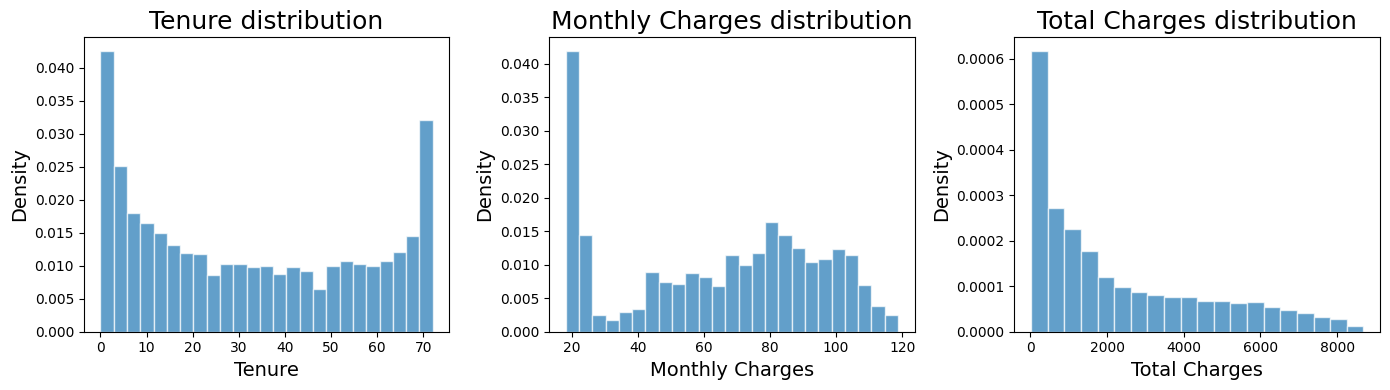

In [152]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(14,4))
# Age distribution
axes[0].hist(df['tenure'], bins=25, density=True, alpha=0.7, edgecolor='white')
axes[0].set_xlabel('Tenure', fontsize=14)
axes[0].set_ylabel('Density', fontsize=14)
axes[0].set_title('Tenure distribution', fontsize=18)

# Gender distribution
# train_df["Gender"].value_counts().plot.pie(autopct='%1.1f%%', textprops={'fontsize': 14}, ax=axes[0][1])
# axes[1].set_title('Gender distribution', fontsize=18)
axes[1].hist(df['MonthlyCharges'], bins=25, density=True, alpha=0.7, edgecolor='white')
axes[1].set_xlabel('Monthly Charges', fontsize=14)
axes[1].set_ylabel('Density', fontsize=14)
axes[1].set_title('Monthly Charges distribution', fontsize=18)

# Tenure distribution
axes[2].hist(df['TotalCharges'], bins=20, density=True, alpha=0.7, edgecolor='white')
axes[2].set_xlabel('Total Charges', fontsize=14)
axes[2].set_ylabel('Density', fontsize=14)
axes[2].set_title('Total Charges distribution', fontsize=18)
plt.tight_layout()



In [153]:
num_cols=['tenure','MonthlyCharges', 'TotalCharges'] 
cat_cols=['MultipleLines', 'InternetService', 'OnlineSecurity','OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV','StreamingMovies','PaymentMethod' ]
passthrough_cols =['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'Contract', 'PaperlessBilling',] 
print(df.columns.difference(num_cols + cat_cols+passthrough_cols))
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols),
        ("num", StandardScaler(), num_cols),
    ],
    remainder="passthrough"
)


Index(['Churn'], dtype='str')


In [154]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import recall_score, accuracy_score, f1_score, precision_score, confusion_matrix
from sklearn.model_selection import train_test_split
X = df.drop('Churn', axis=1)
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
results_df= pd.DataFrame(columns=['Model','Recall','Accuracy', 'Precision', 'Confusion Martix'])

## Logistic Regression

In [155]:
from sklearn.linear_model import LogisticRegression
lr_pipeline = Pipeline([
    ("preprocessing", preprocessor),  
    ("model", LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced"))
])
param_grid = {"model__C": [0.01, 0.1, 1, 10], "model__solver": ["liblinear","lbfgs","saga"]}
lr_grid_search= GridSearchCV(estimator=lr_pipeline, param_grid=param_grid, cv=5, scoring="accuracy", n_jobs=-1, verbose=1)
lr_grid_search.fit(X_train,y_train)
best_lr_model= lr_grid_search.best_estimator_

y_pred=best_lr_model.predict(X_test)
lr_accuracy= accuracy_score(y_test,y_pred)*100
lr_recall= recall_score(y_test,y_pred)*100
lr_precision = precision_score(y_test, y_pred)*100
lr_cm=confusion_matrix(y_test, y_pred)
print("Logistic Regression Recall:", round(lr_recall,2),"%")
print("Logistic Regression Accuracy:", round(lr_accuracy,2),"%")
print("Logistic Regression Precision:", round(lr_precision,2),"%")
results_df.loc[len(results_df)]=['Logistic Regression',lr_recall,lr_accuracy,lr_precision,lr_cm]

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Logistic Regression Recall: 78.34 %
Logistic Regression Accuracy: 73.95 %
Logistic Regression Precision: 50.6 %


## Random Forest

In [156]:
from sklearn.ensemble import RandomForestClassifier
rf_pipeline = Pipeline([
    ("preprocessing", preprocessor),  
    ("Classifier", RandomForestClassifier(random_state=42,class_weight="balanced"))
])

param_grid = {"Classifier__n_estimators":[100, 200, 300],"Classifier__criterion":['gini', 'entropy'],"Classifier__max_depth":[5, 10, None],'Classifier__min_samples_split': [2, 5],'Classifier__max_features': ['sqrt', 'log2']}
rf_grid_search= GridSearchCV(estimator=rf_pipeline, param_grid=param_grid, cv=5, scoring="recall", n_jobs=-1, verbose=1)
rf_grid_search.fit(X_train,y_train)
best_rf_model= rf_grid_search.best_estimator_ 
print("Random Forest CV Recall:", rf_grid_search.best_score_)

y_pred=best_rf_model.predict(X_test)
rf_accuracy= accuracy_score(y_test,y_pred) *100
rf_recall= recall_score(y_test,y_pred)*100
rf_precision = precision_score(y_test, y_pred)*100
rf_cm=confusion_matrix(y_test, y_pred)
print("Random Forest Recall:", round(rf_recall,2),"%")
print("Random Forest Accuracy:", round(rf_accuracy,2),"%")
print("Random Forest Precision:", round(rf_precision,2),"%")
results_df.loc[len(results_df)]=['Random Forest',rf_recall,rf_accuracy,rf_precision,rf_cm]

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Random Forest CV Recall: 0.8133779264214047
Random Forest Recall: 80.21 %
Random Forest Accuracy: 73.95 %
Random Forest Precision: 50.59 %


## LightGBM

In [157]:
from lightgbm import LGBMClassifier
import warnings
warnings.filterwarnings("ignore")
lgbm_pipeline = Pipeline([
    ("preprocessing", preprocessor),  
    ("Classifier", LGBMClassifier(random_state=42,class_weight="balanced",verbosity=-1))
])

param_grid = {"Classifier__n_estimators":[100, 200, 300],'Classifier__num_leaves': [15, 31, 63],"Classifier__max_depth":[5, 10, None],'Classifier__learning_rate': [0.01,0.05, 0.1]}
lgbm_grid_search= GridSearchCV(estimator=lgbm_pipeline, param_grid=param_grid, cv=5, scoring="recall_macro", n_jobs=-1, verbose=1)
lgbm_grid_search.fit(X_train,y_train)
best_lgbm_model= lgbm_grid_search.best_estimator_

y_pred=best_lgbm_model.predict(X_test)
lgbm_accuracy= accuracy_score(y_test,y_pred)*100
lgbm_recall= recall_score(y_test,y_pred)*100
lgbm_precision = precision_score(y_test, y_pred)*100
lgbm_cm=confusion_matrix(y_test, y_pred)

print("LightGBM Recall:", round(lgbm_recall,2),"%")
print("LightGBM Accuracy:", round(lgbm_accuracy,2),"%")
print("LightGBM Precision:", round(lgbm_precision,2),"%")
results_df.loc[len(results_df)]=['LightGBM',lgbm_recall,lgbm_accuracy,lgbm_precision,lgbm_cm]

Fitting 5 folds for each of 81 candidates, totalling 405 fits
LightGBM Recall: 81.02 %
LightGBM Accuracy: 76.01 %
LightGBM Precision: 53.16 %


## XGBoost

In [ ]:
from xgboost import XGBClassifier

from collections import Counter
ratio = Counter(y_train)[0] / Counter(y_train)[1]

xgb_pipeline = Pipeline([
    ("preprocessing", preprocessor),  
    ("Classifier", XGBClassifier(random_state=42, scale_pos_weight=ratio))
])

param_grid = {"Classifier__n_estimators": [100, 200, 300], "Classifier__max_depth": [3, 5, 7, 10], "Classifier__learning_rate": [0.01, 0.05, 0.1, 0.2]}
xgb_grid_search= GridSearchCV(estimator=xgb_pipeline, param_grid=param_grid, cv=5, scoring="recall_macro", n_jobs=-1, verbose=1)
xgb_grid_search.fit(X_train,y_train)
best_xgb_model= xgb_grid_search.best_estimator_
# print("XGBoost CV accuracy:", xgb_grid_search.best_score_)

y_pred=best_xgb_model.predict(X_test)
xgb_accuracy= accuracy_score(y_test,y_pred)*100
xgb_recall= recall_score(y_test,y_pred)*100
xgb_precision = precision_score(y_test, y_pred)*100
xgb_cm=confusion_matrix(y_test, y_pred)

print("XGBoost Recall:", round(xgb_recall,2),"%")
print("XGBoost Accuracy:", round(xgb_accuracy,2),"%")
print("XGBoost Precision:", round(xgb_precision,2),"%")
results_df.loc[len(results_df)]=['XGBoost',xgb_recall,xgb_accuracy,xgb_precision,xgb_cm]

Fitting 5 folds for each of 48 candidates, totalling 240 fits
XGBoost Recall: 80.21 %
XGBoost Accuracy: 75.09 %
XGBoost Precision: 51.99 %


## CatBoost

In [ ]:
from catboost import CatBoostClassifier

cat_pipeline = Pipeline([
    ("preprocessing", preprocessor),  
    ("Classifier", CatBoostClassifier(random_state=42,scale_pos_weight=ratio, verbose=0))
])

param_grid = {"Classifier__n_estimators":[100, 200, 300],'Classifier__l2_leaf_reg': [1, 3, 5], "Classifier__depth":[3, 5, 7],'Classifier__learning_rate': [0.01,0.05, 0.1, 0.2]}
cat_grid_search= GridSearchCV(estimator=cat_pipeline, param_grid=param_grid, cv=5, scoring="recall_macro", n_jobs=-1, verbose=1)
cat_grid_search.fit(X_train,y_train)
best_cat_model= cat_grid_search.best_estimator_
# print("XGBoost CV accuracy:", cat_grid_search.best_score_)

y_pred=best_cat_model.predict(X_test)
cat_accuracy= accuracy_score(y_test,y_pred)*100
cat_recall= recall_score(y_test,y_pred)*100
cat_precision = precision_score(y_test, y_pred)*100
cat_cm=confusion_matrix(y_test, y_pred)

print("Catboost Recall:", round(cat_recall,2),"%")
print("Catboost Accuracy:", round(cat_accuracy,2),"%")
print("Catboost Precision:", round(cat_precision,2),"%")
results_df.loc[len(results_df)]=['Catboost',cat_recall,cat_accuracy,cat_precision,cat_cm]


Fitting 5 folds for each of 108 candidates, totalling 540 fits
Catboost Recall: 79.95 %
Catboost Accuracy: 73.74 %
Catboost Precision: 50.34 %


In [160]:
results_df.sort_values(by='Recall',ascending=False,inplace=True)
results_df

,Model,Recall,Accuracy,Precision,Confusion Martix
2,LightGBM,81.016043,76.011356,53.157895,"[[768, 267], [71, 303]]"
3,XGBoost,80.213904,75.088715,51.993068,"[[758, 277], [74, 300]]"
1,Random Forest,80.213904,73.953158,50.590219,"[[742, 293], [74, 300]]"
4,Catboost,79.946524,73.740241,50.336700,"[[740, 295], [75, 299]]"
0,Logistic Regression,78.342246,73.953158,50.604491,"[[749, 286], [81, 293]]"


Best Model: LightGBM
Recall= 81.02 %
Accuracy= 76.01 %


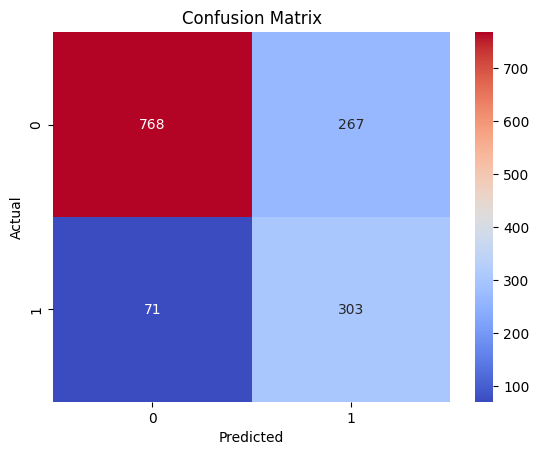

In [161]:
import seaborn as sns

print("Best Model:",results_df['Model'].iloc[0])
print("Recall=", round(results_df['Recall'].iloc[0],2),"%")
print("Accuracy=", round(results_df['Accuracy'].iloc[0],2),"%")

sns.heatmap(results_df['Confusion Martix'].iloc[0], annot=True, cmap='coolwarm',fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [162]:
# We can enhance the Recall by changing the threashold But that will decrease the accuracy 

y_probs = best_lgbm_model.predict_proba(X_test)[:, 1]
thresholds = np.arange(0.1, 0.9, 0.05)
for t in thresholds:
    y_pred_thresh = (y_probs >= t).astype(int)
    accuracy= accuracy_score(y_test,y_pred_thresh)*100
    recall= recall_score(y_test,y_pred_thresh)*100
    print(f"Threshold {t:.2f} -> Recall: {recall:.2f} | Accuracy: {accuracy:.2f}")

Threshold 0.10 -> Recall: 99.20 | Accuracy: 48.05
Threshold 0.15 -> Recall: 97.59 | Accuracy: 54.72
Threshold 0.20 -> Recall: 96.79 | Accuracy: 56.78
Threshold 0.25 -> Recall: 94.92 | Accuracy: 59.47
Threshold 0.30 -> Recall: 93.58 | Accuracy: 63.95
Threshold 0.35 -> Recall: 89.57 | Accuracy: 67.92
Threshold 0.40 -> Recall: 86.36 | Accuracy: 71.33
Threshold 0.45 -> Recall: 83.42 | Accuracy: 73.46
Threshold 0.50 -> Recall: 81.02 | Accuracy: 76.01
Threshold 0.55 -> Recall: 75.94 | Accuracy: 76.15
Threshold 0.60 -> Recall: 71.93 | Accuracy: 78.14
Threshold 0.65 -> Recall: 64.17 | Accuracy: 79.49
Threshold 0.70 -> Recall: 55.08 | Accuracy: 80.13
Threshold 0.75 -> Recall: 45.45 | Accuracy: 79.63
Threshold 0.80 -> Recall: 30.75 | Accuracy: 78.28
Threshold 0.85 -> Recall: 14.44 | Accuracy: 76.30


In [ ]:
# I will use the 0.5 threshold
# import joblib
# joblib.dump({"model": best_lgbm_model,"features": X_train.columns.tolist()}, "churn_model.pkl")

['churn_model.pkl']

In [165]:
print(df.dtypes)
print(df.head())

gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract              int64
PaperlessBilling      int64
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object
   gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0       0              0        1           0       1             0   
1       1              0        0           0      34             1   
2       1              0        0           0       2             1   
3       1              0        0           0      45             0   
4       0              0        0           0       2             1   
